In [1]:
#===============================
# Step 1: Load the package
#===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

In [2]:
#===============================
# Step 2: Load the raw data 
#===============================
print("Dataset loading ...")
df = pd.read_csv("../data/raw/loan_data.csv")
print("Dataset loaded successfully !")
print("shape of dataset",df.shape)
print(df.head())

Dataset loading ...
Dataset loaded successfully !
shape of dataset (1000, 12)
   gender married dependents     education self_employed  applicant_income  \
0    Male     Yes          2  Not Graduate            No            6898.0   
1    Male     Yes          0      Graduate            No           11532.0   
2  Female     Yes         3+      Graduate            No            2705.0   
3    Male     Yes          1      Graduate            No           13671.0   
4    Male     Yes          0      Graduate            No            8459.0   

   coapplicant_income  loan_amount  loan_term  credit_history property_area  \
0               450.0        498.0      480.0             1.0         Urban   
1              3009.0        301.0      120.0             1.0     Semiurban   
2              3419.0         67.0      480.0             1.0         Rural   
3              4394.0        453.0      360.0             NaN         Urban   
4              3433.0        477.0      360.0             

In [7]:
#======================================
# Total income
#======================================
df['total_income']=df['applicant_income'] +df['coapplicant_income']


In [8]:
#======================================
# EMI proxy: loan amount per month
#======================================
df["emi_proxy"] = df["loan_amount"] / (df["loan_term"] + 1e-3)

In [9]:
#=======================
# Loan to income ratio
#=======================
df["loan_to_income"] = df["loan_amount"] / (df["total_income"] + 1e-3)

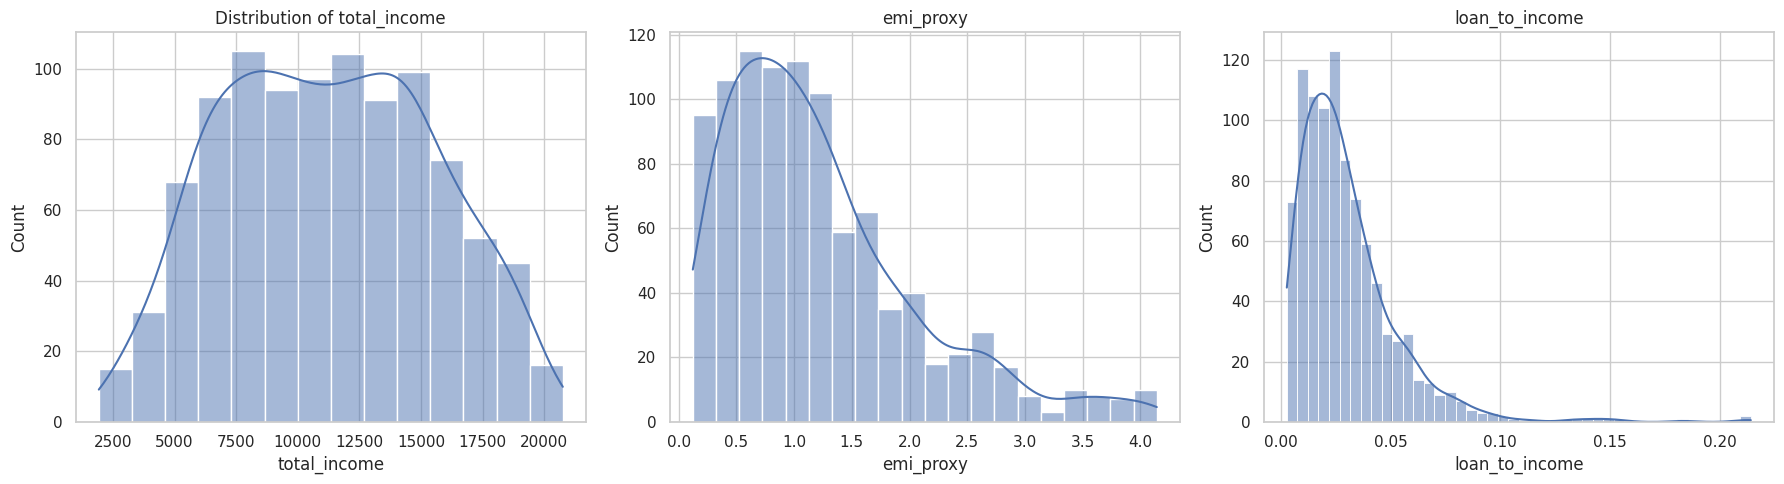

In [10]:
# 📊 5. Visualize the New Features

# Plot distributions of the new features to check if they make sense

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['total_income'], kde=True, ax=axs[0])
axs[0].set_title('Distribution of total_income')

sns.histplot(df['emi_proxy'], kde=True, ax=axs[1])
axs[1].set_title('emi_proxy')

sns.histplot(df['loan_to_income'], kde=True, ax=axs[2])
axs[2].set_title('loan_to_income')

plt.tight_layout()
plt.show()

In [11]:
df.columns

Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'applicant_income', 'coapplicant_income', 'loan_amount', 'loan_term',
       'credit_history', 'property_area', 'loan_status', 'total_income',
       'emi_proxy', 'loan_to_income'],
      dtype='object')

In [31]:
select_columns =['gender', 'married', 'dependents', 'education', 'self_employed',
       'applicant_income', 'coapplicant_income', 'loan_amount', 'loan_term',
       'credit_history', 'property_area', 'loan_status', 'total_income',
       'emi_proxy', 'loan_to_income']

df[select_columns].to_csv("../data/processed/featured.csv", index=False)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              1000 non-null   object 
 1   married             1000 non-null   object 
 2   dependents          1000 non-null   object 
 3   education           1000 non-null   object 
 4   self_employed       1000 non-null   object 
 5   applicant_income    1000 non-null   float64
 6   coapplicant_income  983 non-null    float64
 7   loan_amount         969 non-null    float64
 8   loan_term           1000 non-null   float64
 9   credit_history      912 non-null    float64
 10  property_area       1000 non-null   object 
 11  loan_status         1000 non-null   object 
 12  total_income        983 non-null    float64
 13  emi_proxy           969 non-null    float64
 14  loan_to_income      952 non-null    float64
dtypes: float64(8), object(7)
memory usage: 117.3+ KB


In [25]:
df['self_employed']
df['gender']
df['married']
df['dependents'].value_counts()
df['education'].value_counts()

education
Graduate        785
Not Graduate    215
Name: count, dtype: int64

In [26]:
df['loan_status'].value_counts()

loan_status
Y    874
N    126
Name: count, dtype: int64

In [27]:
df['property_area'].value_counts()

property_area
Urban        399
Semiurban    334
Rural        267
Name: count, dtype: int64